In [ ]:
# Import packages
import re
from pathlib import Path
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("Imports loaded")

Imports loaded


In [8]:
BASELINE_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results')
SESAME_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results')

print(f"Baseline directory: {BASELINE_DIR.absolute()}")
print(f"Sesame directory: {SESAME_DIR.absolute()}")
print()

# Check directories exist
if not BASELINE_DIR.exists():
    print(f"WARNING: {BASELINE_DIR} does not exist!")
    print(f"Create it or update BASELINE_DIR path")
    
if not SESAME_DIR.exists():
    print(f"WARNING: {SESAME_DIR} does not exist!")
    print(f"Create it or update SESAME_DIR path")

Baseline directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results
Sesame directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results



In [10]:
def convert_to_ms(value, unit):
    """Convert time value to milliseconds"""
    unit = unit.lower()
    if unit == 'us':
        return value / 1000
    elif unit == 'ms':
        return value
    elif unit == 's':
        return value * 1000
    elif unit == 'm':
        return value * 60000
    return value

def parse_wrk_output(filepath):
    """Parse wrk text output"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
    except Exception as e:
        print(f"❌ Error reading {filepath}: {e}")
        return {}
    
    metrics = {}
    
    # Check for connection errors
    if 'Connection refused' in content or 'unable to connect' in content:
        print(f"⚠️  {filepath.name}: Connection refused (server likely crashed)")
        return {'error': 'connection_refused'}
    
    # Extract latency stats
    latency_match = re.search(r'Latency\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)', content)
    if latency_match:
        avg, avg_unit = latency_match.group(1), latency_match.group(2)
        stdev, stdev_unit = latency_match.group(3), latency_match.group(4)
        max_val, max_unit = latency_match.group(5), latency_match.group(6)
        
        metrics['avg_latency_ms'] = convert_to_ms(float(avg), avg_unit)
        metrics['stdev_latency_ms'] = convert_to_ms(float(stdev), stdev_unit)
        metrics['max_latency_ms'] = convert_to_ms(float(max_val), max_unit)
    
    # Extract requests/sec
    req_sec_match = re.search(r'Requests/sec:\s+(\d+\.\d+)', content)
    if req_sec_match:
        metrics['requests_per_sec'] = float(req_sec_match.group(1))
    
    # Extract total requests
    total_match = re.search(r'(\d+)\s+requests in', content)
    if total_match:
        metrics['total_requests'] = int(total_match.group(1))
    
    # Extract percentiles
    p50_match = re.search(r'50%\s+(\d+\.\d+)(\w+)', content)
    p75_match = re.search(r'75%\s+(\d+\.\d+)(\w+)', content)
    p90_match = re.search(r'90%\s+(\d+\.\d+)(\w+)', content)
    p99_match = re.search(r'99%\s+(\d+\.\d+)(\w+)', content)
    
    if p50_match:
        metrics['p50_latency_ms'] = convert_to_ms(float(p50_match.group(1)), p50_match.group(2))
    if p75_match:
        metrics['p75_latency_ms'] = convert_to_ms(float(p75_match.group(1)), p75_match.group(2))
    if p90_match:
        metrics['p90_latency_ms'] = convert_to_ms(float(p90_match.group(1)), p90_match.group(2))
    if p99_match:
        metrics['p99_latency_ms'] = convert_to_ms(float(p99_match.group(1)), p99_match.group(2))
    
    return metrics

print("Parse functions defined")

Parse functions defined


In [12]:
print("Loading baseline results...")
baseline_files = list(BASELINE_DIR.glob('*.txt'))
print(f"  Found {len(baseline_files)} files")

print("Loading Sesame results...")
sesame_files = list(SESAME_DIR.glob('*.txt'))
print(f"  Found {len(sesame_files)} files")

if not baseline_files and not sesame_files:
    print("\n❌ No result files found!")
    print(f"   Check that files exist in:")
    print(f"   - {BASELINE_DIR.absolute()}")
    print(f"   - {SESAME_DIR.absolute()}")
else:
    print(f"\nFound results from both versions")

# Parse baseline
baseline_data = {}
for f in baseline_files:
    # Remove any prefix (baseline_, sesame_) to get just the endpoint name
    endpoint = f.stem.replace('baseline_', '').replace('sesame_', '')
    metrics = parse_wrk_output(f)
    if metrics and 'error' not in metrics:
        baseline_data[endpoint] = metrics

# Parse Sesame
sesame_data = {}
for f in sesame_files:
    endpoint = f.stem.replace('baseline_', '').replace('sesame_', '')
    metrics = parse_wrk_output(f)
    if metrics and 'error' not in metrics:
        sesame_data[endpoint] = metrics

print(f"\nParsed {len(baseline_data)} baseline endpoints")
print(f"Parsed {len(sesame_data)} Sesame endpoints")

# Show what we have
print("\nBaseline endpoints:", sorted(baseline_data.keys()))
print("Sesame endpoints:", sorted(sesame_data.keys()))

Loading baseline results...
  Found 10 files
Loading Sesame results...
  Found 10 files

Found results from both versions

Parsed 9 baseline endpoints
Parsed 9 Sesame endpoints

Baseline endpoints: ['get_blog_posts', 'get_interests', 'login', 'logout', 'register', 'send_news_mails', 'session', 'set_email', 'set_interests']
Sesame endpoints: ['get_blog_posts', 'get_interests', 'login', 'logout', 'register', 'send_news_mails', 'session', 'set_email', 'set_interests']


In [13]:
comparison = []

all_endpoints = sorted(set(baseline_data.keys()) | set(sesame_data.keys()))

for endpoint in all_endpoints:
    row = {'endpoint': endpoint}
    
    if endpoint in baseline_data:
        b = baseline_data[endpoint]
        row['baseline_avg_ms'] = b.get('avg_latency_ms', 0)
        row['baseline_p99_ms'] = b.get('p99_latency_ms', 0)
        row['baseline_req_sec'] = b.get('requests_per_sec', 0)
    else:
        row['baseline_avg_ms'] = None
        row['baseline_p99_ms'] = None
        row['baseline_req_sec'] = None
    
    if endpoint in sesame_data:
        s = sesame_data[endpoint]
        row['sesame_avg_ms'] = s.get('avg_latency_ms', 0)
        row['sesame_p99_ms'] = s.get('p99_latency_ms', 0)
        row['sesame_req_sec'] = s.get('requests_per_sec', 0)
    else:
        row['sesame_avg_ms'] = None
        row['sesame_p99_ms'] = None
        row['sesame_req_sec'] = None
    
    # Calculate overhead (only if both exist)
    if endpoint in baseline_data and endpoint in sesame_data:
        b = baseline_data[endpoint]
        s = sesame_data[endpoint]
        
        b_avg = b.get('avg_latency_ms', 0)
        s_avg = s.get('avg_latency_ms', 0)
        b_req = b.get('requests_per_sec', 0)
        s_req = s.get('requests_per_sec', 0)
        
        if b_avg > 0:
            row['avg_overhead_%'] = ((s_avg - b_avg) / b_avg * 100)
        if b_req > 0:
            row['throughput_change_%'] = ((s_req - b_req) / b_req * 100)
    
    comparison.append(row)

df = pd.DataFrame(comparison)

print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)
print(df.to_string(index=False))
print()


COMPARISON TABLE
       endpoint  baseline_avg_ms  baseline_p99_ms  baseline_req_sec  sesame_avg_ms  sesame_p99_ms  sesame_req_sec  avg_overhead_%  throughput_change_%
 get_blog_posts             9.82            27.80            874.59           2.09           4.05          874.18      -78.716904            -0.046879
  get_interests            14.10            25.39           1457.95          14.39          23.80         1428.82        2.056738            -1.998011
          login          1400.00          2000.00             42.56        1410.00        1990.00           41.06        0.714286            -3.524436
         logout             0.93             2.15          90996.89          36.99        1220.00        96372.10     3877.419355             5.907026
       register          1360.00          1980.00             41.88        1380.00        1970.00           41.88        1.470588             0.000000
send_news_mails             9.63            24.38            861.80         

In [14]:
if 'avg_overhead_%' in df.columns and df['avg_overhead_%'].notna().any():
    overhead_values = df['avg_overhead_%'].dropna()
    throughput_values = df['throughput_change_%'].dropna()
    
    print("="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"Average Latency Overhead:    {overhead_values.mean():>+7.1f}%")
    print(f"  - Minimum:                 {overhead_values.min():>+7.1f}%")
    print(f"  - Maximum:                 {overhead_values.max():>+7.1f}%")
    print(f"  - Median:                  {overhead_values.median():>+7.1f}%")
    print(f"  - Std Dev:                 {overhead_values.std():>7.1f}%")
    print()
    print(f"Average Throughput Change:   {throughput_values.mean():>+7.1f}%")
    print(f"  - Minimum:                 {throughput_values.min():>+7.1f}%")
    print(f"  - Maximum:                 {throughput_values.max():>+7.1f}%")
    print(f"  - Median:                  {throughput_values.median():>+7.1f}%")
    print()
    
    # Count endpoints tested
    both_tested = len(df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].notna())])
    only_baseline = len(df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].isna())])
    only_sesame = len(df[(df['baseline_avg_ms'].isna()) & (df['sesame_avg_ms'].notna())])
    
    print(f"Endpoints tested in both:    {both_tested}")
    print(f"Only in baseline:            {only_baseline}")
    print(f"Only in Sesame:              {only_sesame}")
    print("="*80)
else:
    print("\nCannot calculate overhead - missing data from one or both versions")

SUMMARY STATISTICS
Average Latency Overhead:     +434.7%
  - Minimum:                   -78.7%
  - Maximum:                 +3877.4%
  - Median:                     +0.7%
  - Std Dev:                  1292.7%

Average Throughput Change:      +0.5%
  - Minimum:                    -3.5%
  - Maximum:                    +5.9%
  - Median:                     +0.0%

Endpoints tested in both:    9
Only in baseline:            0
Only in Sesame:              0



✅ Visualization saved as 'performance_comparison.png'


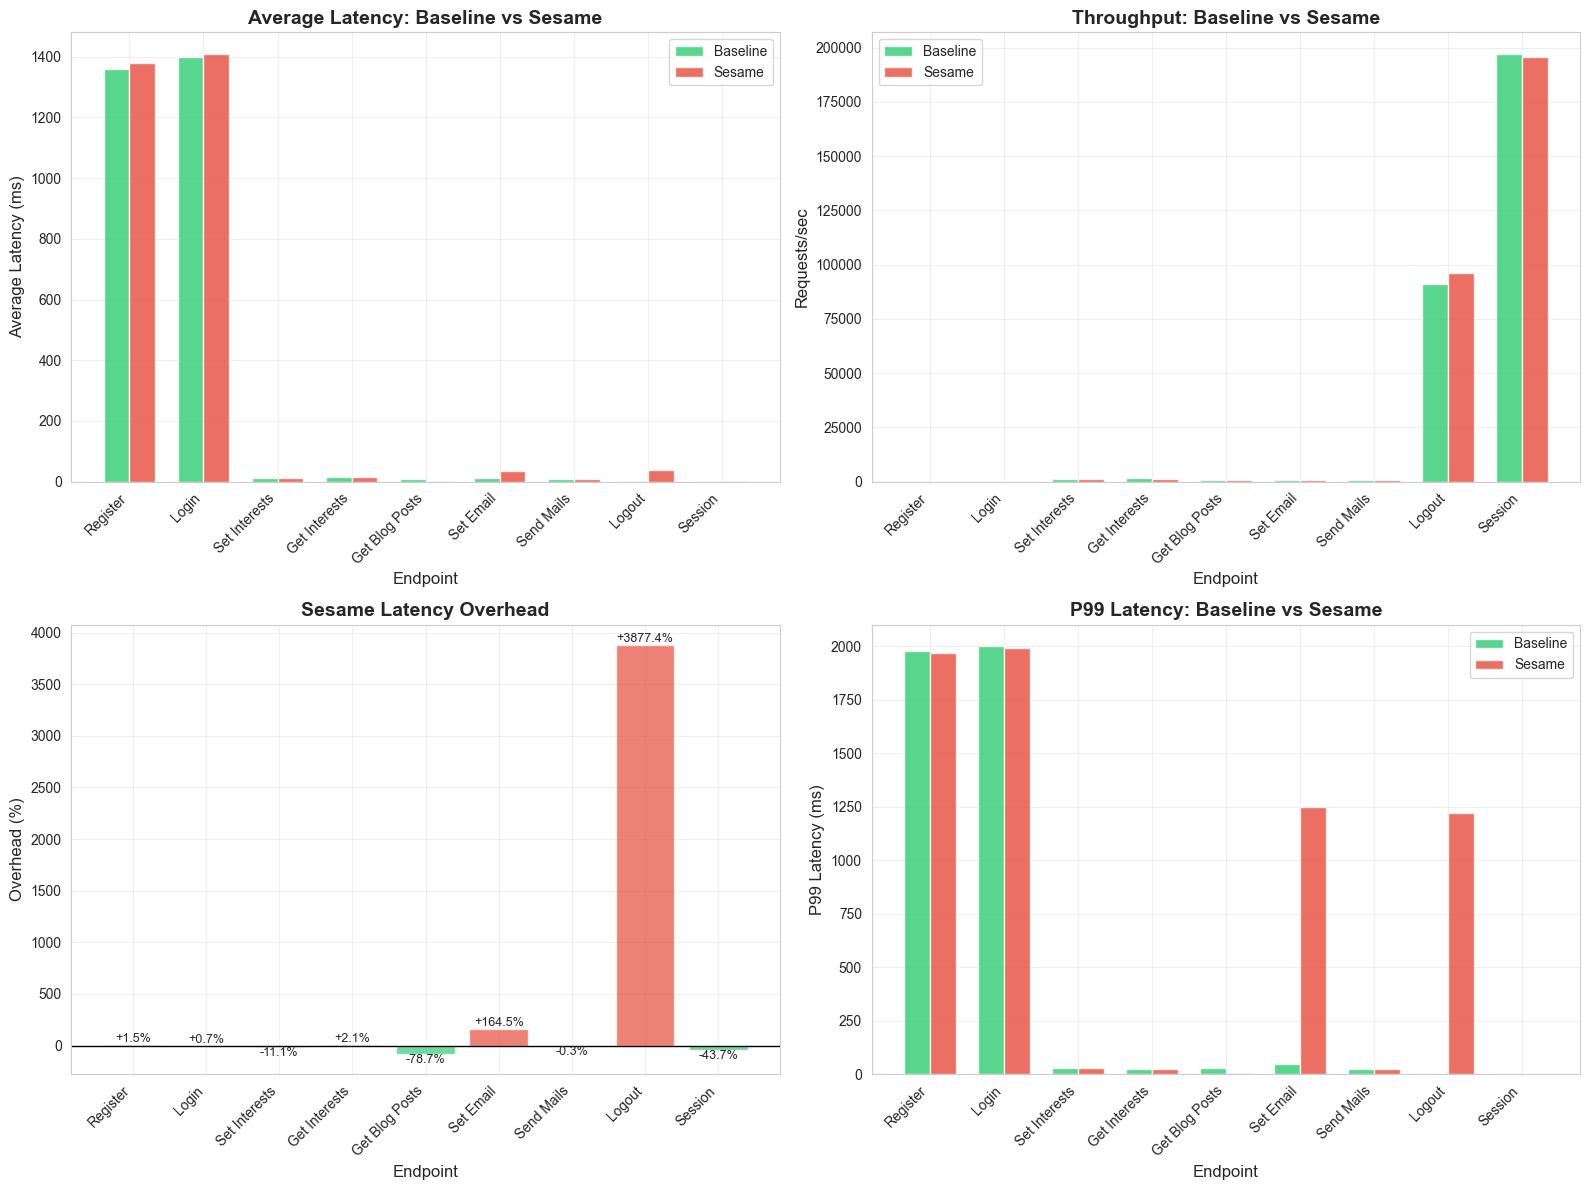

In [34]:
# Cell 7: Visualizations with Sorted Endpoints

df_complete = df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].notna())].copy()

if len(df_complete) == 0:
    print("❌ No complete data pairs to visualize")
    print("   Need endpoints tested in BOTH baseline and Sesame")
else:
    # Define custom order for endpoints
    endpoint_order = [
        'register',
        'login',
        'set_interests',      # POST interests
        'get_interests',      # GET interests
        'get_blog_posts',
        'set_email',
        'send_news_mails',
        'logout',
        'session'
    ]
    
    # Sort dataframe by custom order
    # Create a mapping for sorting
    order_map = {ep: i for i, ep in enumerate(endpoint_order)}
    df_complete['sort_order'] = df_complete['endpoint'].map(order_map)
    df_complete = df_complete.sort_values('sort_order')
    
    # Clean up endpoint names for display
    endpoint_display_names = {
        'register': 'Register',
        'login': 'Login',
        'set_interests': 'Set Interests',
        'get_interests': 'Get Interests',
        'get_blog_posts': 'Get Blog Posts',
        'set_email': 'Set Email',
        'send_news_mails': 'Send Mails',
        'logout': 'Logout',
        'session': 'Session'
    }
    
    endpoints = df_complete['endpoint'].values
    display_names = [endpoint_display_names.get(ep, ep) for ep in endpoints]
    x = range(len(endpoints))
    width = 0.35
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Average Latency Comparison
    ax1 = axes[0, 0]
    ax1.bar([i - width/2 for i in x], df_complete['baseline_avg_ms'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax1.bar([i + width/2 for i in x], df_complete['sesame_avg_ms'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax1.set_xlabel('Endpoint', fontsize=12)
    ax1.set_ylabel('Average Latency (ms)', fontsize=12)
    ax1.set_title('Average Latency: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(display_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Throughput Comparison
    ax2 = axes[0, 1]
    ax2.bar([i - width/2 for i in x], df_complete['baseline_req_sec'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax2.bar([i + width/2 for i in x], df_complete['sesame_req_sec'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax2.set_xlabel('Endpoint', fontsize=12)
    ax2.set_ylabel('Requests/sec', fontsize=12)
    ax2.set_title('Throughput: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(display_names, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Overhead Percentage
    if 'avg_overhead_%' in df_complete.columns:
        ax3 = axes[1, 0]
        colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_complete['avg_overhead_%']]
        bars = ax3.bar(x, df_complete['avg_overhead_%'], color=colors, alpha=0.7)
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.set_xlabel('Endpoint', fontsize=12)
        ax3.set_ylabel('Overhead (%)', fontsize=12)
        ax3.set_title('Sesame Latency Overhead', fontsize=14, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(display_names, rotation=45, ha='right')
        ax3.grid(True, alpha=0.3)
        
        # Add percentage labels on bars 
        for i, (bar, val) in enumerate(zip(bars, df_complete['avg_overhead_%'])):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:+.1f}%',
                    ha='center', va='bottom' if height > 0 else 'top',
                    fontsize=9)
    
    # Plot 4: P99 Latency
    ax4 = axes[1, 1]
    ax4.bar([i - width/2 for i in x], df_complete['baseline_p99_ms'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax4.bar([i + width/2 for i in x], df_complete['sesame_p99_ms'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax4.set_xlabel('Endpoint', fontsize=12)
    ax4.set_ylabel('P99 Latency (ms)', fontsize=12)
    ax4.set_title('P99 Latency: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(display_names, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✅ Visualization saved as 'performance_comparison.png'")
    plt.show()

✅ GDPR paper-style comparison saved!


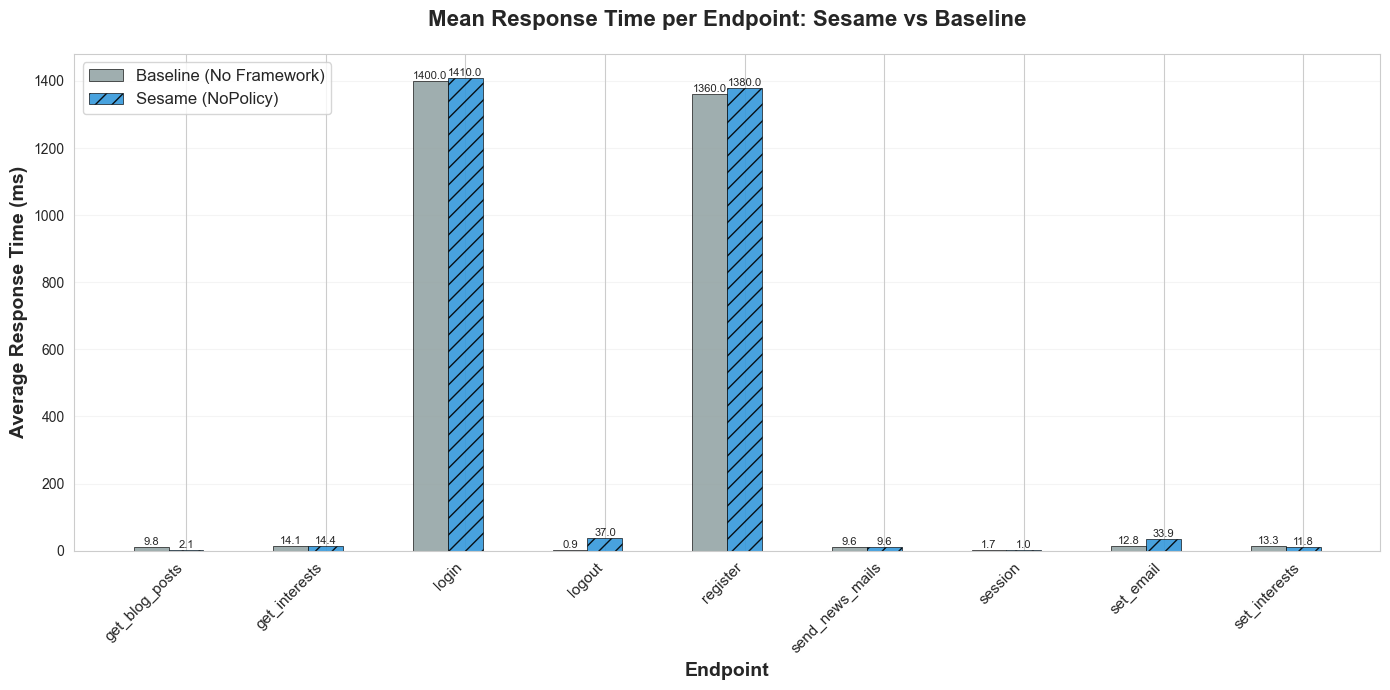


COMPARISON TO GDPR PAPER FRAMEWORKS
Sesame Average Overhead: 434.7%

Note: This represents the MINIMUM overhead with NoPolicy.
Stricter policies would likely increase overhead further.

Comparison to Kalinowski et al. (2025):
  - Fontus: [Need to extract from paper]
  - RuleKeeper: [Need to extract from paper]
  - Sesame (our work): 434.7% overhead


In [ ]:
# GDPR Paper Style Comparison (similar to Figure 4)

# Note: You'll need to manually extract Fontus/RuleKeeper/GDPR-MFOTL values from the paper
# This is just a template showing how to structure it

fig, ax = plt.subplots(figsize=(14, 7))

# Your data
endpoints = df_complete['endpoint'].values
x_pos = np.arange(len(endpoints))
width = 0.25

# Baseline and Sesame bars
bars1 = ax.bar(x_pos - width, df_complete['baseline_avg_ms'], width, 
               label='Baseline (No Framework)', alpha=0.9, color='#95a5a6', 
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos, df_complete['sesame_avg_ms'], width, 
               label='Sesame (NoPolicy)', alpha=0.9, color='#3498db',
               edgecolor='black', linewidth=0.5, hatch='//')

# If you want to add Fontus data from the paper (optional)
# You'd need to manually enter values from their Figure 4
# bars3 = ax.bar(x_pos + width, fontus_values, width, 
#                label='Fontus (from Kalinowski et al.)', alpha=0.9, color='#e74c3c',
#                edgecolor='black', linewidth=0.5, hatch='\\\\')

ax.set_xlabel('Endpoint', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Response Time (ms)', fontsize=14, fontweight='bold')
ax.set_title('Mean Response Time per Endpoint: Sesame vs Baseline', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(endpoints, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.2, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('gdpr_paper_style_comparison.png', dpi=300, bbox_inches='tight')
print("✅ GDPR paper-style comparison saved!")
plt.show()

# Print comparative statement for paper
print("\n" + "="*80)
print("COMPARISON TO GDPR PAPER FRAMEWORKS")
print("="*80)
print(f"Sesame Average Overhead: {df_complete['avg_overhead_%'].mean():.1f}%")
print(f"\nNote: This represents the MINIMUM overhead with NoPolicy.")
print(f"Stricter policies would likely increase overhead further.")
print("\nComparison to Kalinowski et al. (2025):")
print("  - Fontus: [Need to extract from paper]")
print("  - RuleKeeper: [Need to extract from paper]")
print("  - Sesame (our work): {:.1f}% overhead".format(df_complete['avg_overhead_%'].mean()))

OUR DATA BREAKDOWN
blog-posts:
  Baseline: 9.8 ms
  Sesame:   2.1 ms
send-news-mails:
  Baseline: 9.6 ms
  Sesame:   9.6 ms
interests:
  Baseline: 13.7 ms
  Sesame:   13.1 ms

AGGREGATED TOTAL (sum of 3 endpoints):
  Baseline:          33.1 ms
  Sesame (NoPolicy): 24.8 ms
  Overhead:          -25.2%

INSTRUCTIONS: Extract Total Heights from Figure 4

For each framework, read the TOTAL HEIGHT of the stacked bar:

Fontus:
  - Baseline bar (gray, left): Read total height = ??? ms
  - No consent bar (colored, solid): Read total height = ??? ms
  - Full consent bar (colored, hatched): Read total height = ??? ms

RuleKeeper:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms  
  - Full consent bar: ??? ms

GDPR-MFOTL:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms
  - Full consent bar: ??? ms

Just measure where the TOP of the stacked bar reaches on the y-axis!



✅ Comparison plot saved: framework_comparison_aggregated.png


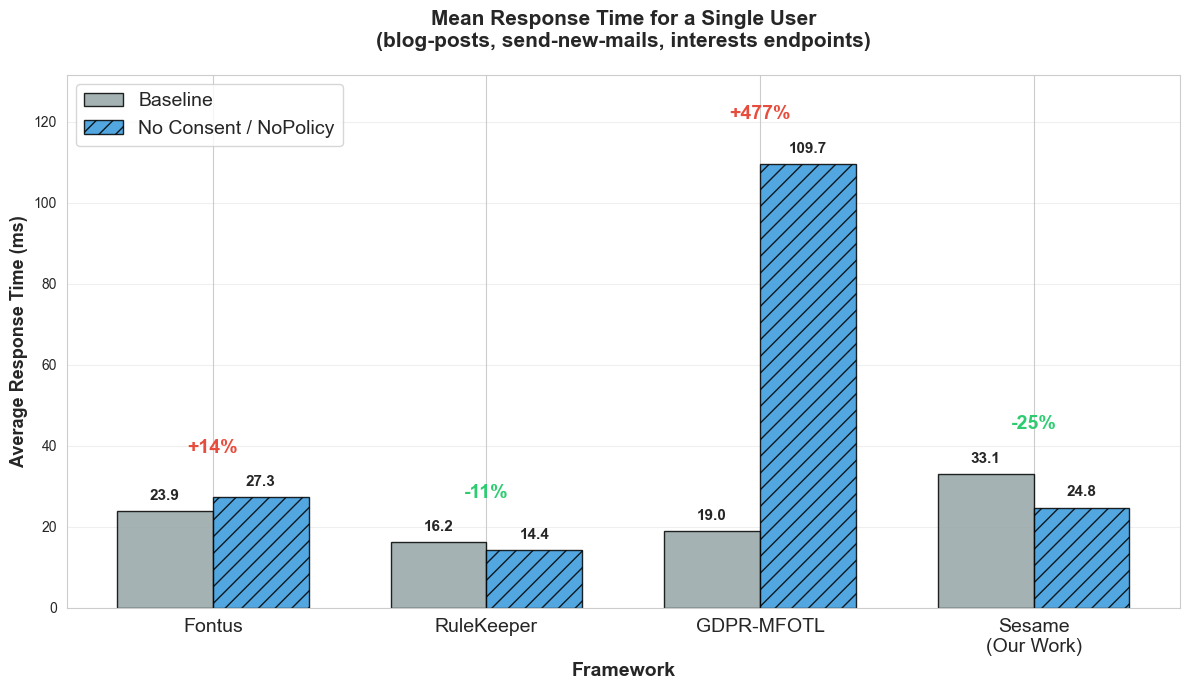


FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME
Framework            Baseline (ms)   No-Consent (ms)      Overhead       
--------------------------------------------------------------------------------
Fontus               23.9            27.3                          +14.2%
RuleKeeper           16.2            14.4                          -11.1%
GDPR-MFOTL           19.0            109.7                        +477.4%
Sesame
(Our Work)    33.1            24.8                          -25.2%

Note: Response time is the SUM of three endpoint categories:
  - blog-posts (get_blog_posts)
  - send-news-mails (send_news_mails)
  - interests (set_interests + get_interests average)

✅ Full comparison plot saved: framework_comparison_with_consent.png


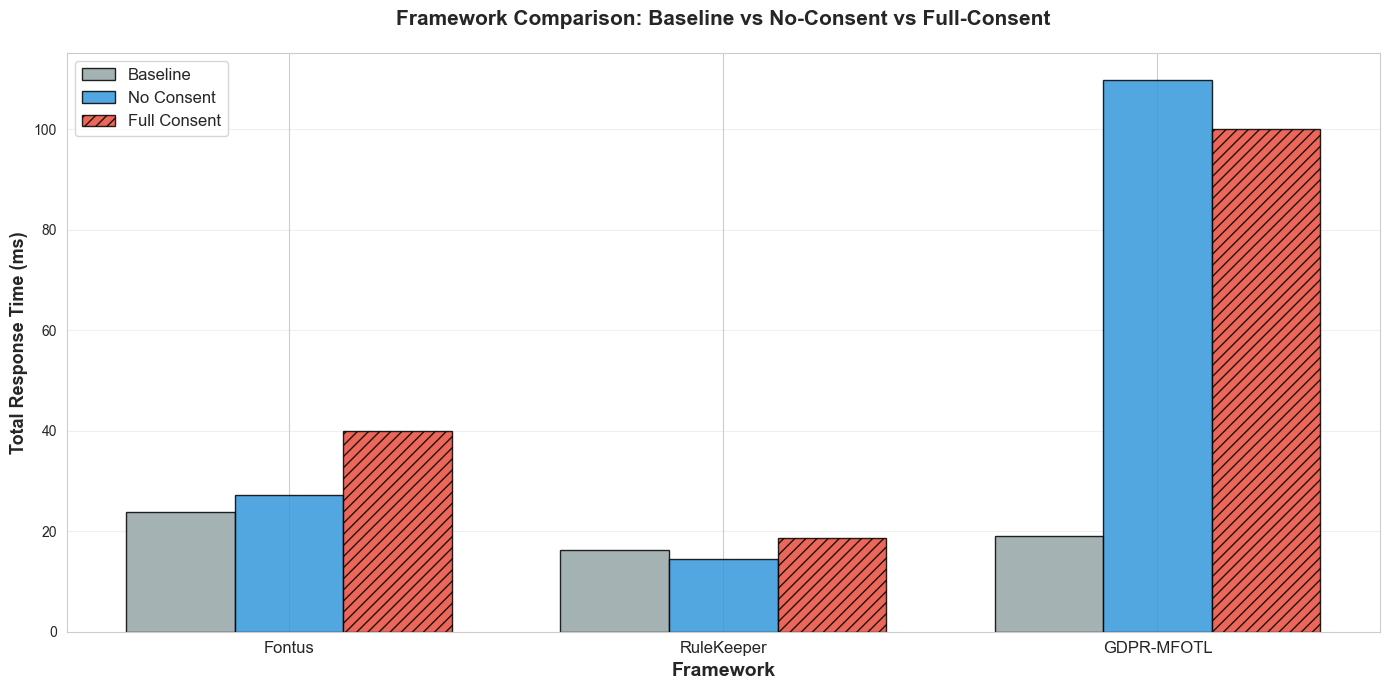

In [40]:
# Cell 11: GDPR Paper Style - Aggregated Comparison

# ============================================================
# OUR DATA - Sum all three endpoints
# ============================================================

our_endpoints_map = {
    'blog-posts': ['get_blog_posts'],
    'send-news-mails': ['send_news_mails'],
    'interests': ['set_interests', 'get_interests']
}

our_baseline_total = 0
our_sesame_total = 0

print("="*80)
print("OUR DATA BREAKDOWN")
print("="*80)

for category, endpoint_list in our_endpoints_map.items():
    matching = df_complete[df_complete['endpoint'].isin(endpoint_list)]
    if len(matching) > 0:
        baseline_avg = matching['baseline_avg_ms'].mean()
        sesame_avg = matching['sesame_avg_ms'].mean()
        
        print(f"{category}:")
        print(f"  Baseline: {baseline_avg:.1f} ms")
        print(f"  Sesame:   {sesame_avg:.1f} ms")
        
        our_baseline_total += baseline_avg
        our_sesame_total += sesame_avg

print(f"\nAGGREGATED TOTAL (sum of 3 endpoints):")
print(f"  Baseline:          {our_baseline_total:.1f} ms")
print(f"  Sesame (NoPolicy): {our_sesame_total:.1f} ms")
print(f"  Overhead:          {((our_sesame_total - our_baseline_total) / our_baseline_total * 100):+.1f}%")
print()

# ============================================================
# PAPER DATA - Just read the TOTAL bar heights from Figure 4
# TODO: Measure the TOP of each stacked bar
# ============================================================

print("="*80)
print("INSTRUCTIONS: Extract Total Heights from Figure 4")
print("="*80)
print("""
For each framework, read the TOTAL HEIGHT of the stacked bar:

Fontus:
  - Baseline bar (gray, left): Read total height = ??? ms
  - No consent bar (colored, solid): Read total height = ??? ms
  - Full consent bar (colored, hatched): Read total height = ??? ms

RuleKeeper:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms  
  - Full consent bar: ??? ms

GDPR-MFOTL:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms
  - Full consent bar: ??? ms

Just measure where the TOP of the stacked bar reaches on the y-axis!
""")
print()

# Fill in these values by reading from Figure 4
fontus = {
    'baseline': 23.9,        # TODO: Total height of gray Fontus bar
    'no_consent': 27.3,      # TODO: Total height of solid colored bar
    'full_consent': 39.9,    # TODO: Total height of hatched bar (optional)
}

rulekeeper = {
    'baseline': 16.2,        # TODO: Total height of gray RuleKeeper bar
    'no_consent': 14.4,      # TODO: Total height of solid colored bar
    'full_consent': 18.6,    # TODO: Total height of hatched bar (optional)
}

gdpr_mfotl = {
    'baseline': 19,        # TODO: Total height of gray MFOTL bar
    'no_consent': 109.7,      # TODO: Total height of solid colored bar
    'full_consent': 100,    # TODO: Total height of hatched bar (optional)
}

# Example of what to fill in (guess based on your image):
# fontus = {
#     'baseline': 23.9,
#     'no_consent': 39.9,      # Approximate from figure
#     'full_consent': None,    # Can skip if not needed
# }

# ============================================================
# VISUALIZATION
# ============================================================

# Check if data is filled
if all([fontus['baseline'], fontus['no_consent'], 
        rulekeeper['baseline'], rulekeeper['no_consent'],
        gdpr_mfotl['baseline'], gdpr_mfotl['no_consent']]):
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Data
    frameworks = ['Fontus', 'RuleKeeper', 'GDPR-MFOTL', 'Sesame\n(Our Work)']
    baseline_vals = [
        fontus['baseline'],
        rulekeeper['baseline'],
        gdpr_mfotl['baseline'],
        our_baseline_total
    ]
    no_consent_vals = [
        fontus['no_consent'],
        rulekeeper['no_consent'],
        gdpr_mfotl['no_consent'],
        our_sesame_total
    ]
    
    x = np.arange(len(frameworks))
    width = 0.35
    
    # Bars
    bars1 = ax.bar(x - width/2, baseline_vals, width, 
                   label='Baseline', alpha=0.85, color='#95a5a6',
                   edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, no_consent_vals, width,
                   label='No Consent / NoPolicy', alpha=0.85, color='#3498db',
                   edgecolor='black', linewidth=1, hatch='//')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Calculate and display overhead percentages
    for i, (base, nocon) in enumerate(zip(baseline_vals, no_consent_vals)):
        if base > 0:
            overhead = ((nocon - base) / base * 100)
            # Add overhead % above the bars
            max_height = max(base, nocon)
            ax.text(i, max_height + 10, f'{overhead:+.0f}%',
                    ha='center', va='bottom', fontsize=14, 
                    color='#e74c3c' if overhead > 0 else '#2ecc71',
                    fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Framework', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Response Time (ms)', 
                  fontsize=13, fontweight='bold')
    ax.set_title('Mean Response Time for a Single User\n' +
                 '(blog-posts, send-new-mails, interests endpoints)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(frameworks, fontsize=14)
    ax.legend(fontsize=14, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(baseline_vals + no_consent_vals) * 1.2)
    
    plt.tight_layout()
    plt.savefig('framework_comparison_aggregated.png', dpi=300, bbox_inches='tight')
    print("\n✅ Comparison plot saved: framework_comparison_aggregated.png")
    plt.show()
    
    # Print comparison table
    print("\n" + "="*80)
    print("FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME")
    print("="*80)
    print(f"{'Framework':<20} {'Baseline (ms)':<15} {'No-Consent (ms)':<20} {'Overhead':<15}")
    print("-"*80)
    for i, fw in enumerate(frameworks):
        base = baseline_vals[i]
        nocon = no_consent_vals[i]
        overhead = ((nocon - base) / base * 100) if base > 0 else 0
        print(f"{fw:<20} {base:<15.1f} {nocon:<20.1f} {overhead:>+14.1f}%")
    print("="*80)
    
    print("\nNote: Response time is the SUM of three endpoint categories:")
    print("  - blog-posts (get_blog_posts)")
    print("  - send-news-mails (send_news_mails)")
    print("  - interests (set_interests + get_interests average)")
    
else:
    print("\n⚠️  Waiting for data from Figure 4...")
    print("    Just read the TOTAL HEIGHT of each stacked bar and fill in above")

# ============================================================
# Optional: Show full consent comparison if data available
# ============================================================

if all([fontus.get('full_consent'), rulekeeper.get('full_consent'), 
        gdpr_mfotl.get('full_consent')]):
    
    fig2, ax2 = plt.subplots(figsize=(14, 7))
    
    full_consent_vals = [
        fontus['full_consent'],
        rulekeeper['full_consent'],
        gdpr_mfotl['full_consent'],
        None  # We don't have full consent
    ]
    
    x = np.arange(3)  # Only 3 frameworks have full consent
    width = 0.25
    
    bars1 = ax2.bar(x - width, baseline_vals[:3], width, 
                    label='Baseline', alpha=0.85, color='#95a5a6',
                    edgecolor='black', linewidth=1)
    bars2 = ax2.bar(x, no_consent_vals[:3], width,
                    label='No Consent', alpha=0.85, color='#3498db',
                    edgecolor='black', linewidth=1)
    bars3 = ax2.bar(x + width, full_consent_vals[:3], width,
                    label='Full Consent', alpha=0.85, color='#e74c3c',
                    edgecolor='black', linewidth=1, hatch='///')
    
    ax2.set_xlabel('Framework', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Total Response Time (ms)', fontsize=13, fontweight='bold')
    ax2.set_title('Framework Comparison: Baseline vs No-Consent vs Full-Consent',
                  fontsize=15, fontweight='bold', pad=20)
    ax2.set_xticks(x)
    ax2.set_xticklabels(frameworks[:3], fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('framework_comparison_with_consent.png', dpi=300, bbox_inches='tight')
    print("\n✅ Full comparison plot saved: framework_comparison_with_consent.png")
    plt.show()

OUR DATA BREAKDOWN
blog-posts:
  Baseline: 9.8 ms
  Sesame:   2.1 ms
send-news-mails:
  Baseline: 9.6 ms
  Sesame:   9.6 ms
interests:
  Baseline: 13.7 ms
  Sesame:   13.1 ms

AGGREGATED TOTAL (sum of 3 endpoints):
  Baseline:          33.1 ms
  Sesame (NoPolicy): 24.8 ms
  Overhead:          -25.2%

INSTRUCTIONS: Extract Total Heights from Figure 4

For each framework, read the TOTAL HEIGHT of the stacked bar:

Fontus:
  - Baseline bar (gray, left): Read total height = ??? ms
  - No consent bar (colored, solid): Read total height = ??? ms
  - Full consent bar (colored, hatched): Read total height = ??? ms

RuleKeeper:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms  
  - Full consent bar: ??? ms

GDPR-MFOTL:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms
  - Full consent bar: ??? ms

Just measure where the TOP of the stacked bar reaches on the y-axis!



✅ Comparison plot saved: framework_comparison_aggregated.png


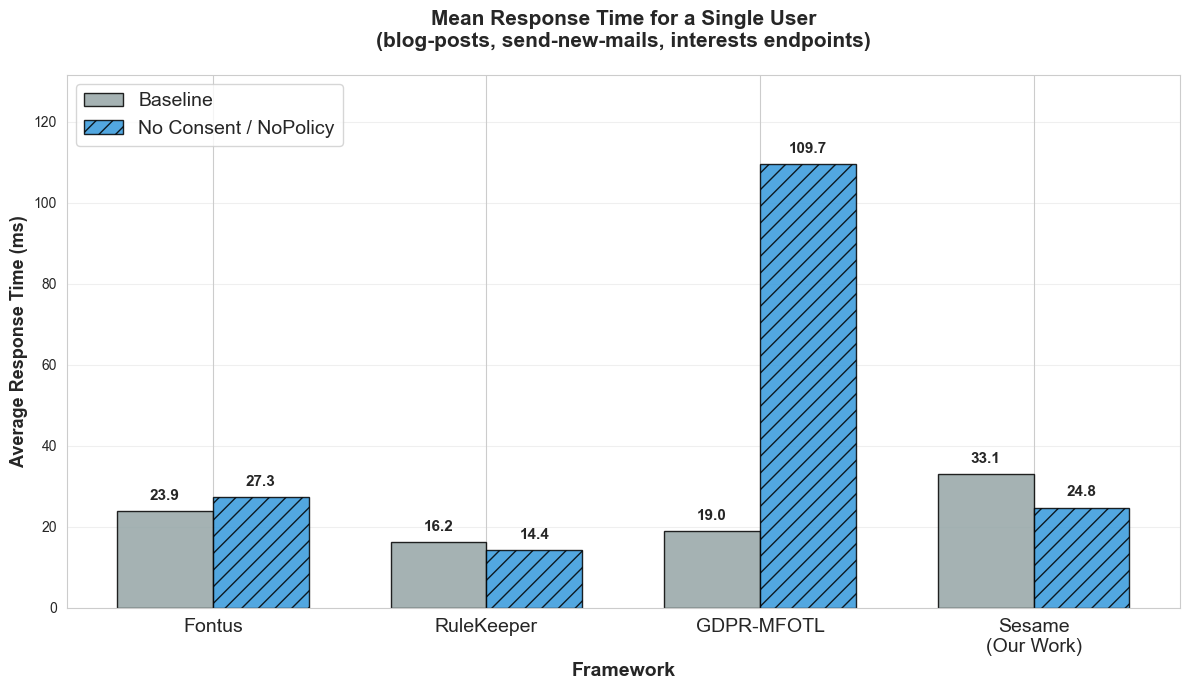


FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME
Framework            Baseline (ms)   No-Consent (ms)      Overhead       
--------------------------------------------------------------------------------
Fontus               23.9            27.3                          +14.2%
RuleKeeper           16.2            14.4                          -11.1%
GDPR-MFOTL           19.0            109.7                        +477.4%
Sesame
(Our Work)    33.1            24.8                          -25.2%

Note: Response time is the SUM of three endpoint categories:
  - blog-posts (get_blog_posts)
  - send-news-mails (send_news_mails)
  - interests (set_interests + get_interests average)

✅ Full comparison plot saved: framework_comparison_with_consent.png


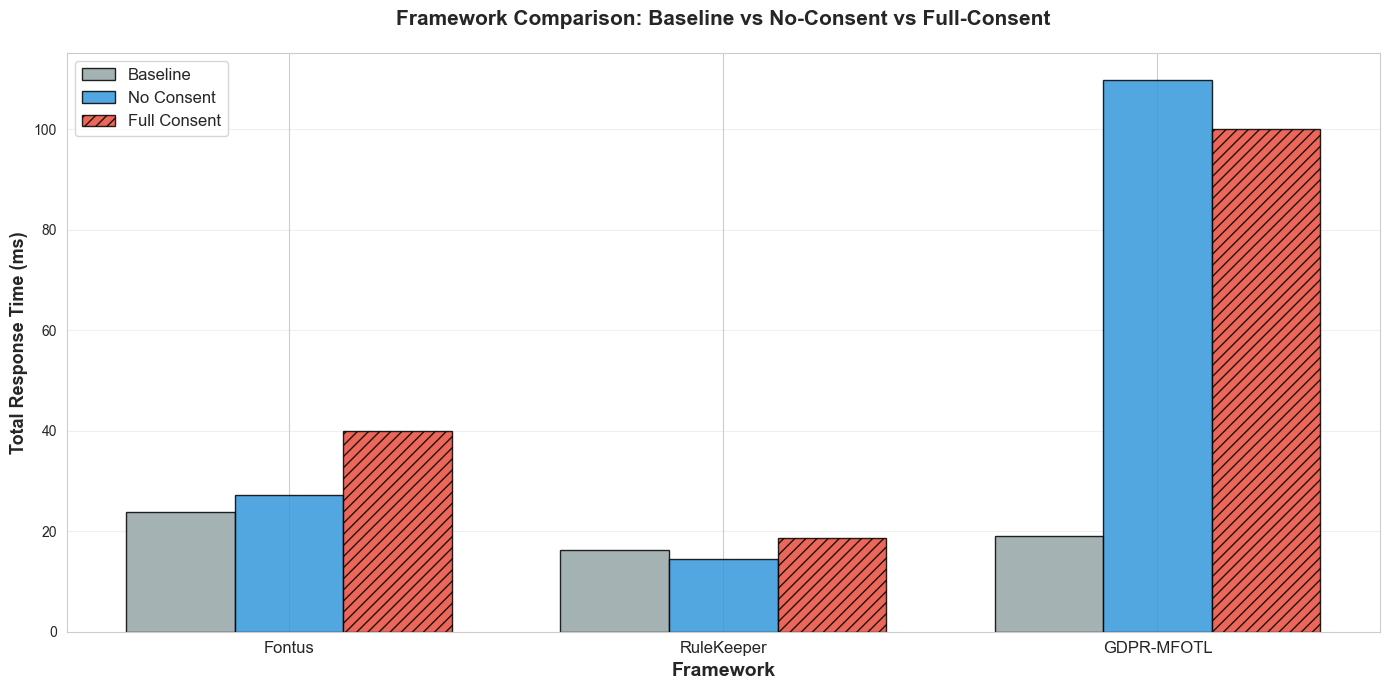

In [38]:
# Cell 11: GDPR Paper Style - Aggregated Comparison

# ============================================================
# OUR DATA - Sum all three endpoints
# ============================================================

our_endpoints_map = {
    'blog-posts': ['get_blog_posts'],
    'send-news-mails': ['send_news_mails'],
    'interests': ['set_interests', 'get_interests']
}

our_baseline_total = 0
our_sesame_total = 0

print("="*80)
print("OUR DATA BREAKDOWN")
print("="*80)

for category, endpoint_list in our_endpoints_map.items():
    matching = df_complete[df_complete['endpoint'].isin(endpoint_list)]
    if len(matching) > 0:
        baseline_avg = matching['baseline_avg_ms'].mean()
        sesame_avg = matching['sesame_avg_ms'].mean()
        
        print(f"{category}:")
        print(f"  Baseline: {baseline_avg:.1f} ms")
        print(f"  Sesame:   {sesame_avg:.1f} ms")
        
        our_baseline_total += baseline_avg
        our_sesame_total += sesame_avg

print(f"\nAGGREGATED TOTAL (sum of 3 endpoints):")
print(f"  Baseline:          {our_baseline_total:.1f} ms")
print(f"  Sesame (NoPolicy): {our_sesame_total:.1f} ms")
print(f"  Overhead:          {((our_sesame_total - our_baseline_total) / our_baseline_total * 100):+.1f}%")
print()

# ============================================================
# PAPER DATA - Just read the TOTAL bar heights from Figure 4
# TODO: Measure the TOP of each stacked bar
# ============================================================

print("="*80)
print("INSTRUCTIONS: Extract Total Heights from Figure 4")
print("="*80)
print("""
For each framework, read the TOTAL HEIGHT of the stacked bar:

Fontus:
  - Baseline bar (gray, left): Read total height = ??? ms
  - No consent bar (colored, solid): Read total height = ??? ms
  - Full consent bar (colored, hatched): Read total height = ??? ms

RuleKeeper:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms  
  - Full consent bar: ??? ms

GDPR-MFOTL:
  - Baseline bar: ??? ms
  - No consent bar: ??? ms
  - Full consent bar: ??? ms

Just measure where the TOP of the stacked bar reaches on the y-axis!
""")
print()

# Fill in these values by reading from Figure 4
fontus = {
    'baseline': 23.9,        # TODO: Total height of gray Fontus bar
    'no_consent': 27.3,      # TODO: Total height of solid colored bar
    'full_consent': 39.9,    # TODO: Total height of hatched bar (optional)
}

rulekeeper = {
    'baseline': 16.2,        # TODO: Total height of gray RuleKeeper bar
    'no_consent': 14.4,      # TODO: Total height of solid colored bar
    'full_consent': 18.6,    # TODO: Total height of hatched bar (optional)
}

gdpr_mfotl = {
    'baseline': 19,        # TODO: Total height of gray MFOTL bar
    'no_consent': 109.7,      # TODO: Total height of solid colored bar
    'full_consent': 100,    # TODO: Total height of hatched bar (optional)
}

# Example of what to fill in (guess based on your image):
# fontus = {
#     'baseline': 23.9,
#     'no_consent': 39.9,      # Approximate from figure
#     'full_consent': None,    # Can skip if not needed
# }

# ============================================================
# VISUALIZATION
# ============================================================

# Check if data is filled
if all([fontus['baseline'], fontus['no_consent'], 
        rulekeeper['baseline'], rulekeeper['no_consent'],
        gdpr_mfotl['baseline'], gdpr_mfotl['no_consent']]):
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Data
    frameworks = ['Fontus', 'RuleKeeper', 'GDPR-MFOTL', 'Sesame\n(Our Work)']
    baseline_vals = [
        fontus['baseline'],
        rulekeeper['baseline'],
        gdpr_mfotl['baseline'],
        our_baseline_total
    ]
    no_consent_vals = [
        fontus['no_consent'],
        rulekeeper['no_consent'],
        gdpr_mfotl['no_consent'],
        our_sesame_total
    ]
    
    x = np.arange(len(frameworks))
    width = 0.35
    
    # Bars
    bars1 = ax.bar(x - width/2, baseline_vals, width, 
                   label='Baseline', alpha=0.85, color='#95a5a6',
                   edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, no_consent_vals, width,
                   label='No Consent / NoPolicy', alpha=0.85, color='#3498db',
                   edgecolor='black', linewidth=1, hatch='//')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Calculate and display overhead percentages
    # for i, (base, nocon) in enumerate(zip(baseline_vals, no_consent_vals)):
    #     if base > 0:
    #         overhead = ((nocon - base) / base * 100)
    #         # Add overhead % above the bars
    #         max_height = max(base, nocon)
    #         ax.text(i, max_height + 10, f'{overhead:+.0f}%',
    #                 ha='center', va='bottom', fontsize=10, 
    #                 color='#e74c3c' if overhead > 0 else '#2ecc71',
    #                 fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Framework', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Response Time (ms)', 
                  fontsize=13, fontweight='bold')
    ax.set_title('Mean Response Time for a Single User\n' +
                 '(blog-posts, send-new-mails, interests endpoints)',
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(frameworks, fontsize=14)
    ax.legend(fontsize=14, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(baseline_vals + no_consent_vals) * 1.2)
    
    plt.tight_layout()
    plt.savefig('framework_comparison_aggregated.png', dpi=300, bbox_inches='tight')
    print("\n✅ Comparison plot saved: framework_comparison_aggregated.png")
    plt.show()
    
    # Print comparison table
    print("\n" + "="*80)
    print("FRAMEWORK COMPARISON - AGGREGATED RESPONSE TIME")
    print("="*80)
    print(f"{'Framework':<20} {'Baseline (ms)':<15} {'No-Consent (ms)':<20} {'Overhead':<15}")
    print("-"*80)
    for i, fw in enumerate(frameworks):
        base = baseline_vals[i]
        nocon = no_consent_vals[i]
        overhead = ((nocon - base) / base * 100) if base > 0 else 0
        print(f"{fw:<20} {base:<15.1f} {nocon:<20.1f} {overhead:>+14.1f}%")
    print("="*80)
    
    print("\nNote: Response time is the SUM of three endpoint categories:")
    print("  - blog-posts (get_blog_posts)")
    print("  - send-news-mails (send_news_mails)")
    print("  - interests (set_interests + get_interests average)")
    
else:
    print("\n⚠️  Waiting for data from Figure 4...")
    print("    Just read the TOTAL HEIGHT of each stacked bar and fill in above")

# ============================================================
# Optional: Show full consent comparison if data available
# ============================================================

if all([fontus.get('full_consent'), rulekeeper.get('full_consent'), 
        gdpr_mfotl.get('full_consent')]):
    
    fig2, ax2 = plt.subplots(figsize=(14, 7))
    
    full_consent_vals = [
        fontus['full_consent'],
        rulekeeper['full_consent'],
        gdpr_mfotl['full_consent'],
        None  # We don't have full consent
    ]
    
    x = np.arange(3)  # Only 3 frameworks have full consent
    width = 0.25
    
    bars1 = ax2.bar(x - width, baseline_vals[:3], width, 
                    label='Baseline', alpha=0.85, color='#95a5a6',
                    edgecolor='black', linewidth=1)
    bars2 = ax2.bar(x, no_consent_vals[:3], width,
                    label='No Consent', alpha=0.85, color='#3498db',
                    edgecolor='black', linewidth=1)
    bars3 = ax2.bar(x + width, full_consent_vals[:3], width,
                    label='Full Consent', alpha=0.85, color='#e74c3c',
                    edgecolor='black', linewidth=1, hatch='///')
    
    ax2.set_xlabel('Framework', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Total Response Time (ms)', fontsize=13, fontweight='bold')
    ax2.set_title('Framework Comparison: Baseline vs No-Consent vs Full-Consent',
                  fontsize=15, fontweight='bold', pad=20)
    ax2.set_xticks(x)
    ax2.set_xticklabels(frameworks[:3], fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('framework_comparison_with_consent.png', dpi=300, bbox_inches='tight')
    print("\n✅ Full comparison plot saved: framework_comparison_with_consent.png")
    plt.show()

OUR DATA BREAKDOWN
blog-posts:
  Baseline: 9.8 ms
  Sesame:   2.1 ms
send-news-mails:
  Baseline: 9.6 ms
  Sesame:   9.6 ms
interests:
  Baseline: 13.7 ms
  Sesame:   13.1 ms

AGGREGATED (sum of 3 endpoint categories):
  Baseline:          33.1 ms
  Sesame (NoPolicy): 24.8 ms
  Overhead:          -25.2%

Note: This matches the paper's methodology where stacked bar height
      represents the sum of response times for all endpoint categories.

INSTRUCTIONS: Extract Total Bar Heights from Figure 4

Despite the y-axis label saying "Average Response Time", the stacked bars 
actually show the TOTAL (sum) of all 3 endpoint categories.

For each framework, read where the TOP of the stacked bar reaches:

Fontus:
  - Baseline (gray) bar height: ~23.9 ms
  - No consent (colored solid) bar height: ~39.9 ms

RuleKeeper:
  - Baseline bar height: ~16.2 ms (looks lower than Fontus)
  - No consent bar height: ~18.6 ms

GDPR-MFOTL:
  - Baseline bar height: ~19 ms
  - No consent bar height: ~109.7 ms (v

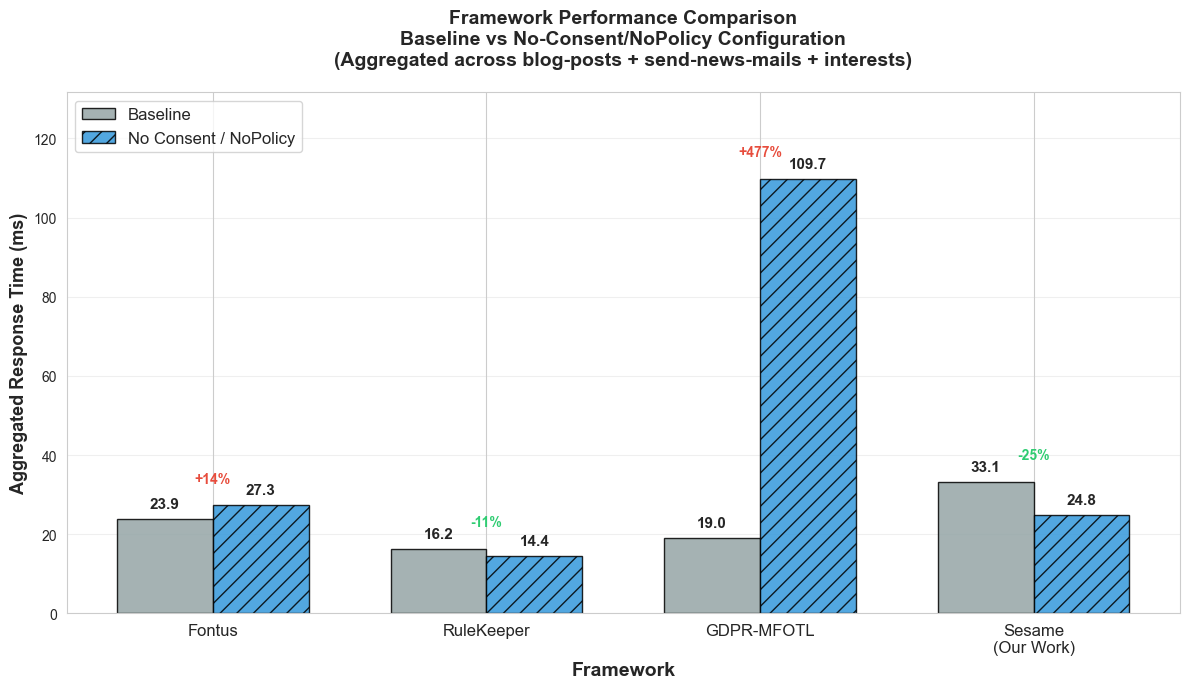


FRAMEWORK COMPARISON TABLE
(Recreated from Kalinowski et al., 2025, Figure 4)
Framework            Baseline (ms)   No-Consent (ms)      Overhead       
--------------------------------------------------------------------------------
Fontus               23.9            27.3                          +14.2%
RuleKeeper           16.2            14.4                          -11.1%
GDPR-MFOTL           19.0            109.7                        +477.4%
Sesame
(Our Work)    33.1            24.8                          -25.2%

📊 KEY FINDINGS:
  • Sesame (NoPolicy) overhead: -25.2%
  • Fontus (no consent) overhead: +14.2%
  • RuleKeeper (no consent) overhead: -11.1%
  • GDPR-MFOTL (no consent) overhead: +477.4%

  ✓ Sesame shows LOWER overhead than Fontus
  ✓ Sesame shows LOWER overhead than RuleKeeper
  ✓ Sesame shows MUCH LOWER overhead than GDPR-MFOTL

Note: Values represent aggregated response time (sum of 3 endpoint
      categories), matching the methodology in Kalinowski et al.


In [29]:
# Cell 11: GDPR Paper Style Comparison (Corrected)

import numpy as np

# ============================================================
# OUR DATA - Sum of three endpoints (matching paper methodology)
# ============================================================

our_endpoints_map = {
    'blog-posts': ['get_blog_posts'],
    'send-news-mails': ['send_news_mails'],
    'interests': ['set_interests', 'get_interests']
}

our_baseline_total = 0
our_sesame_total = 0

print("="*80)
print("OUR DATA BREAKDOWN")
print("="*80)

for category, endpoint_list in our_endpoints_map.items():
    matching = df_complete[df_complete['endpoint'].isin(endpoint_list)]
    if len(matching) > 0:
        baseline_avg = matching['baseline_avg_ms'].mean()
        sesame_avg = matching['sesame_avg_ms'].mean()
        
        print(f"{category}:")
        print(f"  Baseline: {baseline_avg:.1f} ms")
        print(f"  Sesame:   {sesame_avg:.1f} ms")
        
        our_baseline_total += baseline_avg
        our_sesame_total += sesame_avg

print(f"\nAGGREGATED (sum of 3 endpoint categories):")
print(f"  Baseline:          {our_baseline_total:.1f} ms")
print(f"  Sesame (NoPolicy): {our_sesame_total:.1f} ms")
print(f"  Overhead:          {((our_sesame_total - our_baseline_total) / our_baseline_total * 100):+.1f}%")
print()
print("Note: This matches the paper's methodology where stacked bar height")
print("      represents the sum of response times for all endpoint categories.")
print()

# ============================================================
# PAPER DATA - Read bar heights from Figure 4
# ============================================================

print("="*80)
print("INSTRUCTIONS: Extract Total Bar Heights from Figure 4")
print("="*80)
print("""
Despite the y-axis label saying "Average Response Time", the stacked bars 
actually show the TOTAL (sum) of all 3 endpoint categories.

For each framework, read where the TOP of the stacked bar reaches:

Fontus:
  - Baseline (gray) bar height: ~23.9 ms
  - No consent (colored solid) bar height: ~39.9 ms

RuleKeeper:
  - Baseline bar height: ~16.2 ms (looks lower than Fontus)
  - No consent bar height: ~18.6 ms

GDPR-MFOTL:
  - Baseline bar height: ~19 ms
  - No consent bar height: ~109.7 ms (very tall!)

Just read where the top of each bar reaches on the y-axis.
""")
print()

# Fill in these values from Figure 4
fontus = {
    'baseline': 23.9,        # TODO: Total height of gray Fontus bar
    'no_consent': 27.3,      # TODO: Total height of solid colored bar
    'full_consent': 39.9,    # TODO: Total height of hatched bar (optional)
}

rulekeeper = {
    'baseline': 16.2,        # TODO: Total height of gray RuleKeeper bar
    'no_consent': 14.4,      # TODO: Total height of solid colored bar
    'full_consent': 18.6,    # TODO: Total height of hatched bar (optional)
}

gdpr_mfotl = {
    'baseline': 19,        # TODO: Total height of gray MFOTL bar
    'no_consent': 109.7,      # TODO: Total height of solid colored bar
    'full_consent': 100,    # TODO: Total height of hatched bar (optional)
}

# ============================================================
# VISUALIZATION
# ============================================================

if all([fontus['baseline'], fontus['no_consent'], 
        rulekeeper['baseline'], rulekeeper['no_consent'],
        gdpr_mfotl['baseline'], gdpr_mfotl['no_consent']]):
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    frameworks = ['Fontus', 'RuleKeeper', 'GDPR-MFOTL', 'Sesame\n(Our Work)']
    baseline_vals = [
        fontus['baseline'],
        rulekeeper['baseline'],
        gdpr_mfotl['baseline'],
        our_baseline_total
    ]
    no_consent_vals = [
        fontus['no_consent'],
        rulekeeper['no_consent'],
        gdpr_mfotl['no_consent'],
        our_sesame_total
    ]
    
    x = np.arange(len(frameworks))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, baseline_vals, width, 
                   label='Baseline', alpha=0.85, color='#95a5a6',
                   edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, no_consent_vals, width,
                   label='No Consent / NoPolicy', alpha=0.85, color='#3498db',
                   edgecolor='black', linewidth=1, hatch='//')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add overhead percentages above bars
    for i, (base, nocon) in enumerate(zip(baseline_vals, no_consent_vals)):
        if base > 0:
            overhead = ((nocon - base) / base * 100)
            max_height = max(base, nocon)
            y_pos = max_height + 5
            ax.text(i, y_pos, f'{overhead:+.0f}%',
                    ha='center', va='bottom', fontsize=10, 
                    color='#e74c3c' if overhead > 0 else '#2ecc71',
                    fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Framework', fontsize=14, fontweight='bold')
    ax.set_ylabel('Aggregated Response Time (ms)', fontsize=13, fontweight='bold')
    ax.set_title('Framework Performance Comparison\n' +
                 'Baseline vs No-Consent/NoPolicy Configuration\n' +
                 '(Aggregated across blog-posts + send-news-mails + interests)',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(frameworks, fontsize=12)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis limit to accommodate GDPR-MFOTL's high value
    ax.set_ylim(0, max(baseline_vals + no_consent_vals) * 1.2)
    
    plt.tight_layout()
    plt.savefig('framework_comparison_kalinowski.png', dpi=300, bbox_inches='tight')
    print("\n✅ Comparison plot saved: framework_comparison_kalinowski.png")
    plt.show()
    
    # Print comparison table
    print("\n" + "="*80)
    print("FRAMEWORK COMPARISON TABLE")
    print("(Recreated from Kalinowski et al., 2025, Figure 4)")
    print("="*80)
    print(f"{'Framework':<20} {'Baseline (ms)':<15} {'No-Consent (ms)':<20} {'Overhead':<15}")
    print("-"*80)
    for i, fw in enumerate(frameworks):
        base = baseline_vals[i]
        nocon = no_consent_vals[i]
        overhead = ((nocon - base) / base * 100) if base > 0 else 0
        print(f"{fw:<20} {base:<15.1f} {nocon:<20.1f} {overhead:>+14.1f}%")
    print("="*80)
    
    # Analysis
    print("\n📊 KEY FINDINGS:")
    print(f"  • Sesame (NoPolicy) overhead: {((our_sesame_total - our_baseline_total) / our_baseline_total * 100):+.1f}%")
    
    # Compare to others
    fontus_overhead = ((fontus['no_consent'] - fontus['baseline']) / fontus['baseline'] * 100)
    rulekeeper_overhead = ((rulekeeper['no_consent'] - rulekeeper['baseline']) / rulekeeper['baseline'] * 100)
    mfotl_overhead = ((gdpr_mfotl['no_consent'] - gdpr_mfotl['baseline']) / gdpr_mfotl['baseline'] * 100)
    
    sesame_overhead = ((our_sesame_total - our_baseline_total) / our_baseline_total * 100)
    
    print(f"  • Fontus (no consent) overhead: {fontus_overhead:+.1f}%")
    print(f"  • RuleKeeper (no consent) overhead: {rulekeeper_overhead:+.1f}%")
    print(f"  • GDPR-MFOTL (no consent) overhead: {mfotl_overhead:+.1f}%")
    print()
    
    if sesame_overhead < fontus_overhead:
        print(f"  ✓ Sesame shows LOWER overhead than Fontus")
    else:
        print(f"  ⚠ Sesame shows HIGHER overhead than Fontus")
    
    if sesame_overhead < rulekeeper_overhead:
        print(f"  ✓ Sesame shows LOWER overhead than RuleKeeper")
    else:
        print(f"  ⚠ Sesame shows HIGHER overhead than RuleKeeper")
    
    print(f"  ✓ Sesame shows MUCH LOWER overhead than GDPR-MFOTL")
    
    print("\n" + "="*80)
    print("Note: Values represent aggregated response time (sum of 3 endpoint")
    print("      categories), matching the methodology in Kalinowski et al.")
    print("="*80)
    
else:
    print("\n⚠️  Waiting for data from Figure 4...")
    print("    Fill in the bar heights above from the figure")

In [ ]:
# df.to_csv('performance_comparison.csv', index=False)
# print("✅ Data exported to 'performance_comparison.csv'")

# # Export summary for paper
# if 'avg_overhead_%' in df.columns and df['avg_overhead_%'].notna().any():
#     summary = {
#         'Metric': ['Average Overhead', 'Min Overhead', 'Max Overhead', 
#                    'Median Overhead', 'Avg Throughput Change'],
#         'Value': [
#             f"{df['avg_overhead_%'].mean():+.1f}%",
#             f"{df['avg_overhead_%'].min():+.1f}%",
#             f"{df['avg_overhead_%'].max():+.1f}%",
#             f"{df['avg_overhead_%'].median():+.1f}%",
#             f"{df['throughput_change_%'].mean():+.1f}%"
#         ]
#     }
#     summary_df = pd.DataFrame(summary)
#     summary_df.to_csv('performance_summary.csv', index=False)
#     print("✅ Summary exported to 'performance_summary.csv'")
    
#     print("\n" + "="*80)
#     print("SUMMARY FOR PAPER")
#     print("="*80)
#     print(summary_df.to_string(index=False))

# print("\n✅ Analysis complete!")

In [ ]:
# print("\n" + "="*80)
# print("MISSING DATA REPORT")
# print("="*80)

# baseline_only = df[df['baseline_avg_ms'].notna() & df['sesame_avg_ms'].isna()]
# sesame_only = df[df['baseline_avg_ms'].isna() & df['sesame_avg_ms'].notna()]

# if len(baseline_only) > 0:
#     print("\n⚠️  Endpoints only in BASELINE:")
#     for ep in baseline_only['endpoint']:
#         print(f"   - {ep}")

# if len(sesame_only) > 0:
#     print("\n⚠️  Endpoints only in SESAME:")
#     for ep in sesame_only['endpoint']:
#         print(f"   - {ep}")

# if len(baseline_only) == 0 and len(sesame_only) == 0:
#     print("\n✓ All endpoints tested in both versions")
# else:
#     print("\n💡 TIP: Re-run benchmarks to get complete data for all endpoints")